# CV Project

## Preprocessing

In [1]:
from pathlib import Path
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import cv2

Scanning image resolutions... this might take a minute.


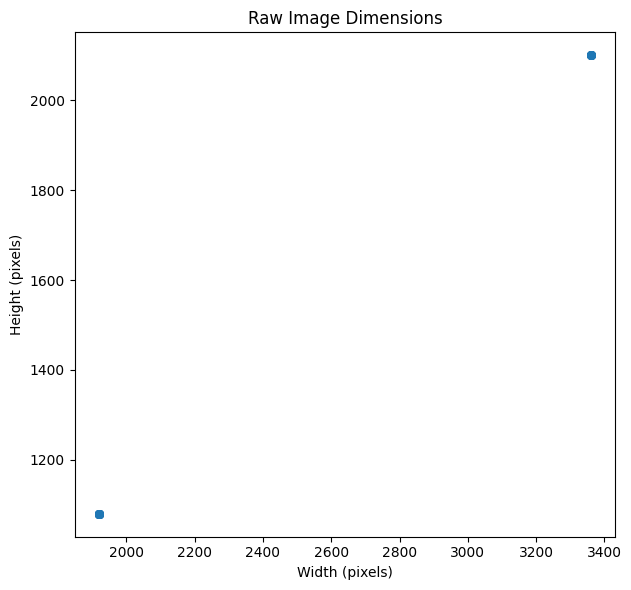

In [2]:
image_dir = Path("./development_set")
data = []

print("Scanning image resolutions... this might take a minute.")
   
for img_path in image_dir.rglob('*.jpg'):
    try:
        with Image.open(img_path) as img:
            width, height = img.size
            data.append({
                "Width": width,
                "Height": height
            })
    except Exception as e:
        pass

df = pd.DataFrame(data)

# --- Plotting the Distribution ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x="Width", y="Height", alpha=0.5, edgecolor=None)
plt.title("Raw Image Dimensions")
plt.xlabel("Width (pixels)")
plt.ylabel("Height (pixels)")

plt.tight_layout()
plt.show()

In [3]:
HEIGHT = 1920 
WIDTH = 1080

input_dir = Path("./development_set")
output_dir = Path("./processed_images")

In [8]:
def process_and_save_image(file_path_str, out_path_str):
     img = cv2.imread(file_path_str)
    
     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

     img_tensor = tf.convert_to_tensor(img, dtype=tf.float32)
     img_resized = tf.image.resize(
         img_tensor, 
         size=[WIDTH , HEIGHT], 
         method=tf.image.ResizeMethod.LANCZOS3
     )                                                                    # resizing images to same resolution

     img_final = tf.cast(tf.clip_by_value(img_resized, 0, 255), tf.uint8) # normalise image
     encoded_img = tf.io.encode_jpeg(img_final, quality=100)
     tf.io.write_file(out_path_str, encoded_img)

In [9]:
for img_path in image_dir.rglob('*.jpg'):
    rel_path = img_path.relative_to(input_dir)
    out_path = output_dir / rel_path.with_suffix('.jpg')
    process_and_save_image(str(img_path), str(out_path))

print(f"Done! All images processed and saved to {output_dir}")

Done! All images processed and saved to processed_images
